In [1]:
# Cell 1 — Imports and connection
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sqlalchemy.engine import URL   ## URL.create() already handles special-character encoding internally, no need to wrap password with quote_plus() anymore.
import os
from dotenv import load_dotenv

sns.set_style('whitegrid')

load_dotenv(dotenv_path='../.env')

url = URL.create(
    drivername='postgresql+psycopg2',
    username=os.getenv('DB_USER'),
    password=os.getenv('DB_PASSWORD'),
    host=os.getenv('DB_HOST'),
    port=int(os.getenv('DB_PORT')),
    database=os.getenv('DB_NAME')
)

engine = create_engine(url)

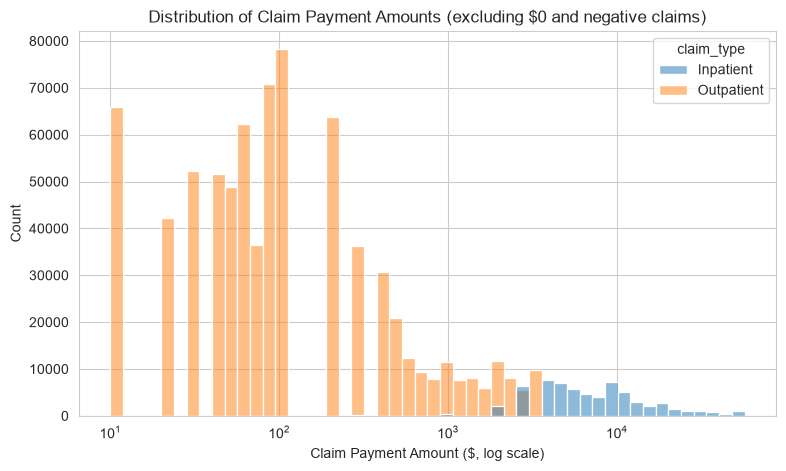

In [9]:
# Cell 2 — Distribution of claim costs (all claims)
all_costs = pd.read_sql("SELECT clm_pmt_amt, claim_type FROM claims_with_beneficiary;", engine)

positive_costs = all_costs[all_costs['clm_pmt_amt'] > 0]

plt.figure(figsize=(9,5))
sns.histplot(data=positive_costs, x='clm_pmt_amt', hue='claim_type', bins=50, log_scale=(True, False))
plt.title('Distribution of Claim Payment Amounts (excluding $0 and negative claims)')
plt.xlabel('Claim Payment Amount ($, log scale)')
plt.show()

In [7]:
print(all_costs.shape)
all_costs.head()

(857563, 2)


,clm_pmt_amt,claim_type
0,4000.0,Inpatient
1,26000.0,Inpatient
2,5000.0,Inpatient
3,5000.0,Inpatient
4,16000.0,Inpatient


In [8]:
print(all_costs['clm_pmt_amt'].describe())
print((all_costs['clm_pmt_amt'] <= 0).sum())

count    857563.000000
mean       1007.255315
std        3640.546992
min       -8000.000000
25%          40.000000
50%          80.000000
75%         300.000000
max       57000.000000
Name: clm_pmt_amt, dtype: float64
34886


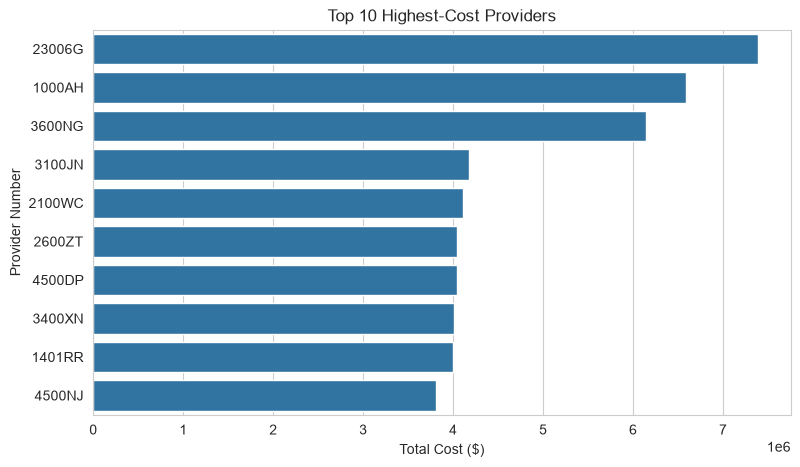

In [3]:
# Cell 3 — Top 10 highest-cost providers (Query 4b)
top_providers = pd.read_sql("""
SELECT prvdr_num, SUM(clm_pmt_amt) AS total_cost, COUNT(*) AS claim_count
FROM claims_with_beneficiary GROUP BY prvdr_num
ORDER BY total_cost DESC LIMIT 10;
""", engine)

plt.figure(figsize=(9,5))
sns.barplot(data=top_providers, y='prvdr_num', x='total_cost', orient='h')
plt.title('Top 10 Highest-Cost Providers')
plt.xlabel('Total Cost ($)')
plt.ylabel('Provider Number')
plt.show()

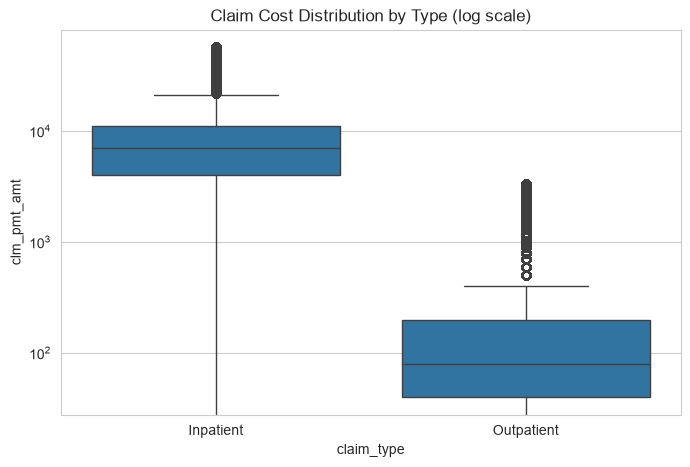

In [4]:
# Cell 4 — Boxplot: cost distribution by claim type (spot outliers/high utilization)
plt.figure(figsize=(8,5))
sns.boxplot(data=all_costs, x='claim_type', y='clm_pmt_amt')
plt.yscale('log')
plt.title('Claim Cost Distribution by Type (log scale)')
plt.show()

In [12]:
# Cell 5 — Save summary tables for use in Tableau dashboard
cost_by_category = pd.read_sql("SELECT claim_type, claim_year, SUM(clm_pmt_amt) AS total_cost FROM claims_with_beneficiary GROUP BY claim_type, claim_year;", engine)
cost_by_category['claim_year'] = cost_by_category['claim_year'].astype('Int64')
cost_by_category.to_csv('../data/processed/summary_cost_by_category.csv', index=False)

top_providers.to_csv('../data/processed/summary_top_providers.csv', index=False)

In [13]:
cost_by_category

,claim_type,claim_year,total_cost
0,Inpatient,2007,2770000.0
1,Inpatient,2008,257732880.0
2,Inpatient,2009,244810270.0
3,Inpatient,2010,132669330.0
4,Inpatient,<NA>,1277700.0
5,Outpatient,2007,265120.0
6,Outpatient,2008,73141190.0
7,Outpatient,2009,87972330.0
8,Outpatient,2010,47913710.0
9,Outpatient,<NA>,15232360.0


In [14]:
top_providers

,prvdr_num,total_cost,claim_count
0,23006G,7383640.0,1085
1,1000AH,6582910.0,2422
2,3600NG,6140850.0,2330
3,3100JN,4172410.0,2401
4,2100WC,4109110.0,653
5,2600ZT,4046330.0,821
6,4500DP,4042410.0,2930
7,3400XN,4008560.0,985
8,1401RR,4003430.0,874
9,4500NJ,3812170.0,4037
